# Week 12 Experiment: DRS Train and Race Pelotons Graph (Interval Graph)

Este notebook contiene los resultados ya compilados de la construcción y análisis del **Grafo de Trenes de DRS y Pelotones de Carrera**.

## Metodología
- **Nodos:** Pilotos (siglas de 3 letras).
- **Aristas (No dirigidas):** Conectan al piloto A y al piloto B si el intervalo de tiempo entre ambos en una vuelta dada es menor a 1.0 segundo (zona de DRS).
- **Pesos:** Proporción de vueltas de la carrera que pasaron en zona de DRS mutua (vueltas en DRS / vueltas totales).
- **Distancias (para Centralidad):** Definida como `1.0 / peso` para que los pares con mayor interacción DRS representen distancias más cortas (más conectadas).
- **Métricas:**
  - **Centralidad de Intermediación (Betweenness Centrality):** Identifica a los pilotos "tapón" (corking/midfield bottlenecks) que sostienen trenes de DRS detrás de sí.
  - **Componentes Conexas:** Agrupa a los pilotos en los "pelotones" físicos que se formaron en la carrera.


In [2]:
import os
import glob
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Setup data paths
raw_path = '../../data/raw'
processed_path = '../../data/processed'
print("Entorno listo.")


Entorno listo.


## 1. GP de Australia 2026
- **Vueltas Totales:** 57
- **Nodos (Pilotos):** 22
- **Aristas (Batallas DRS):** 47


Vueltas Totales: 57
Nodos (Drivers): 22
Edges (DRS): 47

Top 10 Betweenness Centrality (Midfield Bottleneck/Tapón):
     Betweenness Centrality
VER                0.338095
SAI                0.271429
ANT                0.228571
GAS                0.219048
OCO                0.209524
COL                0.190476
HAM                0.161905
ALO                0.154762
BEA                0.123810
RUS                0.085714

Connected Components (Pelotons/DRS Trains): 3 groups
Group 1 (20 drivers): ALB, VER, BOT, HAM, BEA, BOR, GAS, ALO, LAW, STR, ANT, NOR, SAI, PER, RUS, LEC, HAD, OCO, COL, LIN
Group 2 (1 drivers): HUL
Group 3 (1 drivers): PIA


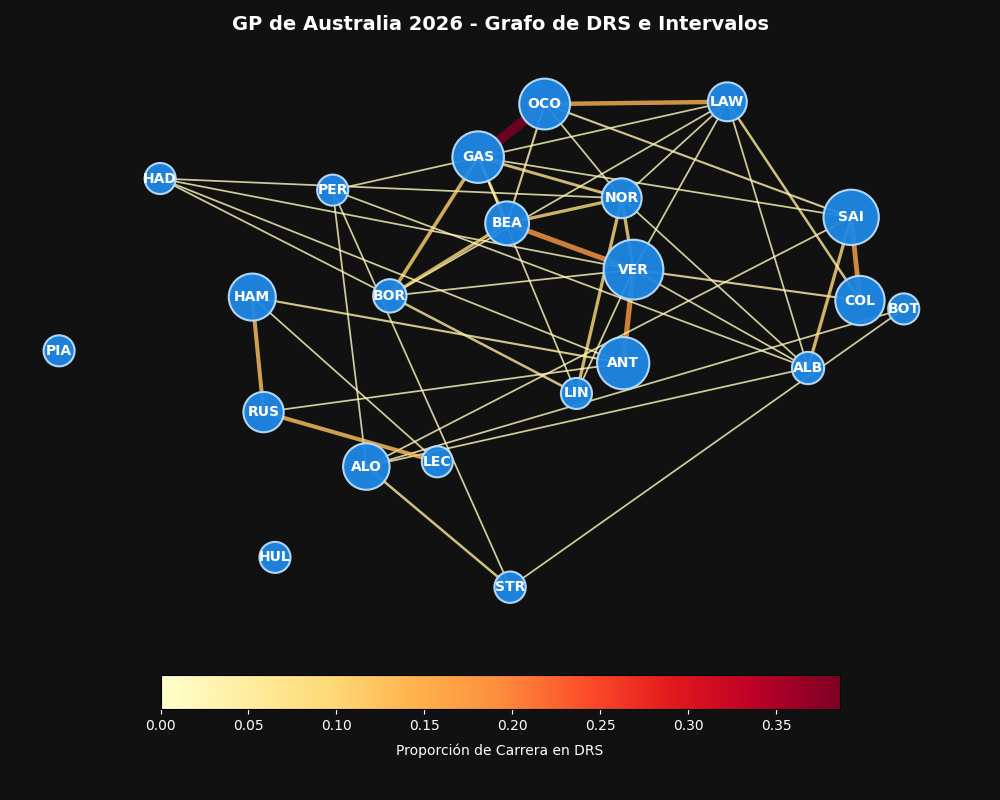

In [4]:
# Cargar y analizar GP de Australia 2026
G_aus, laps_aus = build_drs_interval_graph("australia_2026", raw_path, processed_path)
metrics_aus, comps_aus = calculate_drs_metrics(G_aus)
print(f"Vueltas Totales: {laps_aus}")
print(f"Nodos: {G_aus.number_of_nodes()} | Aristas: {G_aus.number_of_edges()}")
print("\nTop 10 Betweenness Centrality:")
print(metrics_aus.head(10))


## 2. GP de China 2026
- **Vueltas Totales:** 56
- **Nodos (Pilotos):** 22
- **Aristas (Batallas DRS):** 24


Vueltas Totales: 56
Nodos (Drivers): 22
Edges (DRS): 24

Top 10 Betweenness Centrality (Midfield Bottleneck/Tapón):
     Betweenness Centrality
HUL                0.085714
OCO                0.061905
LEC                0.042857
LAW                0.019048
LIN                0.019048
PIA                0.000000
BOT                0.000000
RUS                0.000000
SAI                0.000000
HAM                0.000000

Connected Components (Pelotons/DRS Trains): 12 groups
Group 1 (11 drivers): HUL, ALO, GAS, VER, LAW, STR, LIN, ANT, LEC, HAD, OCO
Group 2 (1 drivers): NOR
Group 3 (1 drivers): BOR
Group 4 (1 drivers): PER
Group 5 (1 drivers): ALB
Group 6 (1 drivers): COL
Group 7 (1 drivers): HAM
Group 8 (1 drivers): SAI
Group 9 (1 drivers): RUS
Group 10 (1 drivers): BOT
Group 11 (1 drivers): PIA
Group 12 (1 drivers): BEA


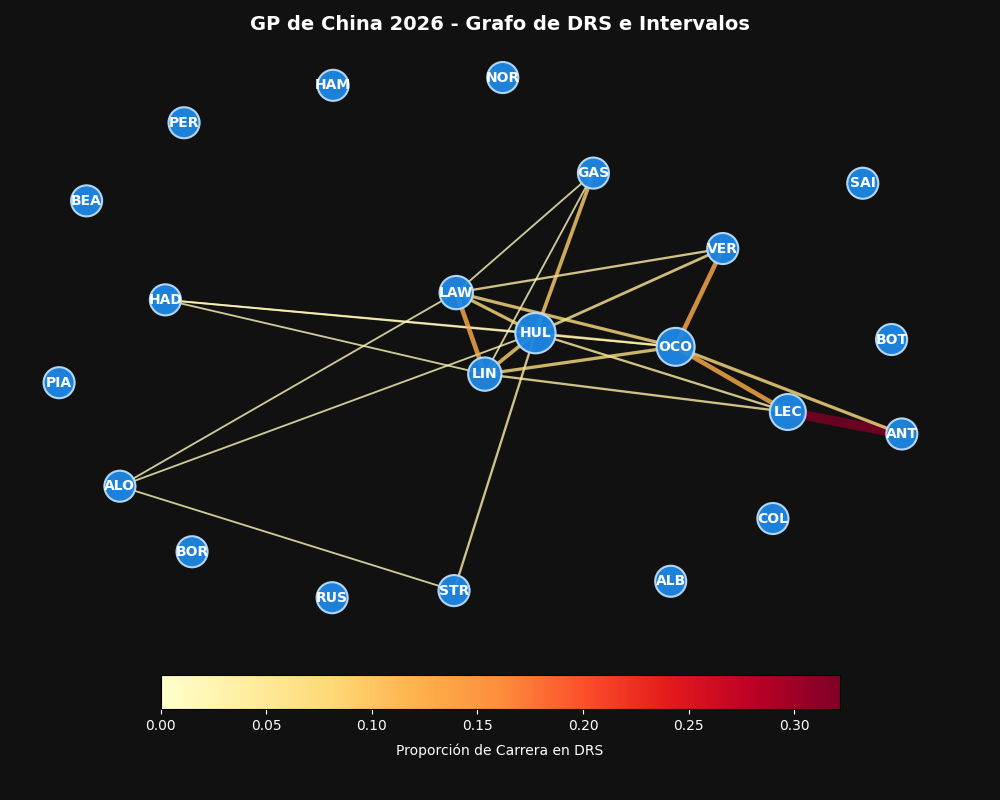

In [6]:
# Cargar y analizar GP de China 2026
G_chn, laps_chn = build_drs_interval_graph("china_2026", raw_path, processed_path)
metrics_chn, comps_chn = calculate_drs_metrics(G_chn)
print(f"Vueltas Totales: {laps_chn}")
print(f"Nodos: {G_chn.number_of_nodes()} | Aristas: {G_chn.number_of_edges()}")
print("\nTop 10 Betweenness Centrality:")
print(metrics_chn.head(10))


## 3. GP de Estados Unidos 2026
- **Vueltas Totales:** 57
- **Nodos (Pilotos):** 22
- **Aristas (Batallas DRS):** 80


Vueltas Totales: 57
Nodos (Drivers): 22
Edges (DRS): 80

Top 10 Betweenness Centrality (Midfield Bottleneck/Tapón):
     Betweenness Centrality
BOR                0.304762
ALO                0.228571
BEA                0.219048
ALB                0.209524
RUS                0.133333
OCO                0.090476
LEC                0.080952
SAI                0.066667
PIA                0.052381
BOT                0.052381

Connected Components (Pelotons/DRS Trains): 2 groups
Group 1 (21 drivers): ALB, VER, BOT, HAM, BEA, BOR, ALO, GAS, STR, LAW, ANT, NOR, SAI, PER, PIA, RUS, LEC, HAD, OCO, COL, LIN
Group 2 (1 drivers): HUL


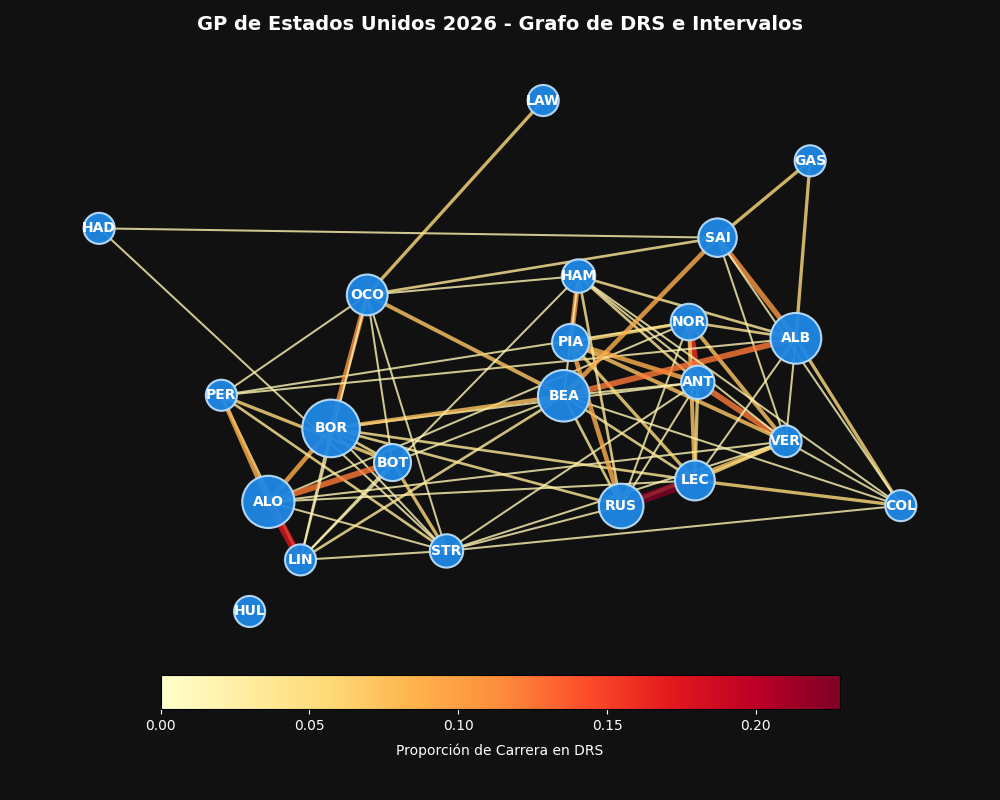

In [8]:
# Cargar y analizar GP de Estados Unidos 2026
G_usa, laps_usa = build_drs_interval_graph("united_states_2026", raw_path, processed_path)
metrics_usa, comps_usa = calculate_drs_metrics(G_usa)
print(f"Vueltas Totales: {laps_usa}")
print(f"Nodos: {G_usa.number_of_nodes()} | Aristas: {G_usa.number_of_edges()}")
print("\nTop 10 Betweenness Centrality:")
print(metrics_usa.head(10))


## 4. Temporada 2026 (Consolidado Global)
- **Vueltas Totales (carreras con intervalos):** 170
- **Nodos (Pilotos):** 22
- **Aristas (Batallas DRS):** 122


Vueltas Totales: 170
Nodos (Drivers): 22
Edges (DRS): 122

Top 10 Global Betweenness Centrality (Midfield Bottleneck/Tapón):
     Betweenness Centrality
OCO                0.247619
ALO                0.240476
LIN                0.230952
LEC                0.204762
BEA                0.128571
ANT                0.123810
VER                0.090476
RUS                0.085714
BOR                0.066667
NOR                0.061905

Connected Components (Global Pelotons): 1 groups
Group 1 (22 drivers): ALB, VER, BOT, HAM, BEA, BOR, ALO, GAS, LAW, STR, ANT, NOR, SAI, PER, PIA, RUS, LEC, HAD, OCO, HUL, COL, LIN


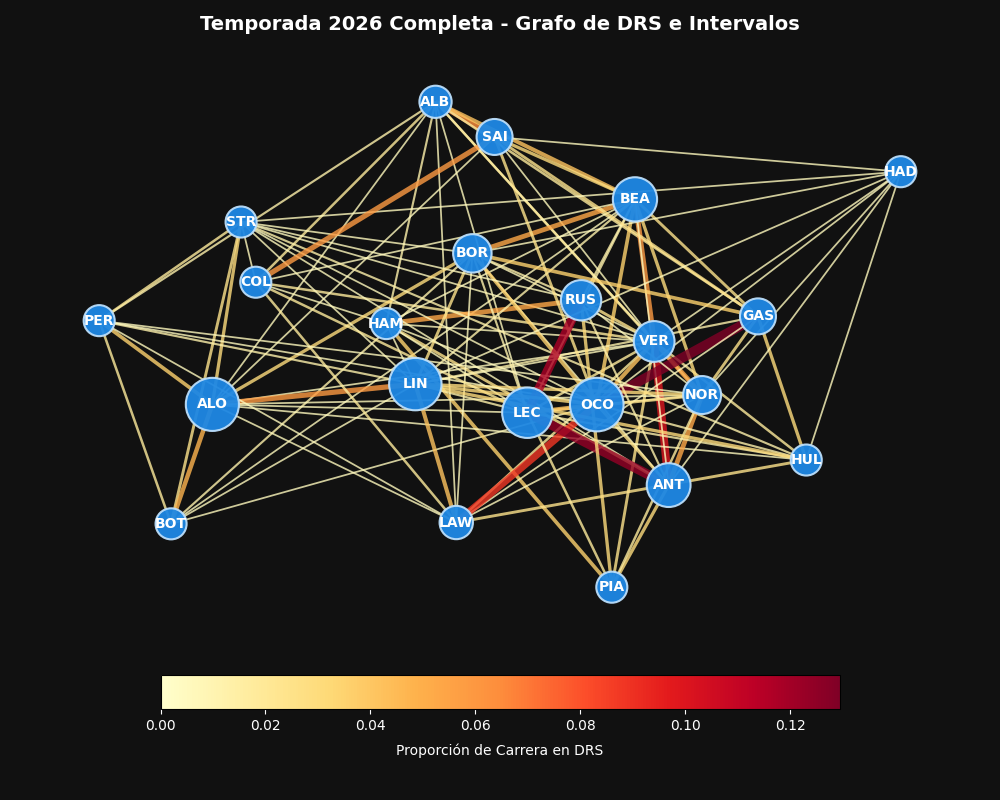

In [10]:
# Cargar y analizar Grafo Global
G_glb, laps_glb = build_global_drs_interval_graph(raw_path, processed_path, ["australia_2026", "china_2026", "united_states_2026"])
metrics_glb, comps_glb = calculate_drs_metrics(G_glb)
print(f"Vueltas Totales Acumuladas: {laps_glb}")
print(f"Nodos: {G_glb.number_of_nodes()} | Aristas: {G_glb.number_of_edges()}")
print("\nTop 10 Global Betweenness Centrality:")
print(metrics_glb.head(10))
